# 02 · Churn prediction model and retention targeting

**Goal:** predict which customers are likely to churn, then turn the prediction into a retention decision:
*how many customers should we target, and is the campaign worth the cost?*

**Approach**
1. Feature engineering (business-readable bands and ratios)
2. Compare 6 classifiers plus stacking and soft-voting ensembles with **10-fold stratified cross-validation**
3. Evaluate the chosen model on a held-out 20% test set
4. Translate scores into a **gains curve** and an illustrative **campaign ROI** scenario

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from churn.data import FIGURES_DIR, TARGET, AGE_BINS, AGE_LABELS, load_data

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=0.95)
CHURN, STAY = "#C0392B", "#2E86C1"
pd.set_option("display.float_format", "{:.3f}".format)

from sklearn.inspection import permutation_importance
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, classification_report,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

from churn.data import (ENGINEERED_CATEGORICAL, ENGINEERED_NUMERIC, RAW_CATEGORICAL,
                        RAW_NUMERIC, add_features)
from churn.modeling import (SEED, base_models, cross_validate_models, ensemble_models,
                            gains_table, make_pipeline, retention_campaign_profit)

## 1. Features and train/test split

In [2]:
df = add_features(load_data())
X, y = df.drop(columns=[TARGET]), df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows | Churn rate train/test: "
      f"{y_train.mean():.1%} / {y_test.mean():.1%}")

Train: 8,000 rows | Test: 2,000 rows | Churn rate train/test: 20.4% / 20.3%


| New feature | Why |
|---|---|
| `age_band` | churn jumps after 40; bands make the non-linear effect easy for linear models |
| `products_group` | 1 / 2 / 3+ products behave very differently (2 is the sweet spot) |
| `zero_balance` | 36% of customers hold no balance and churn less |
| `balance_to_salary` | how much of a customer's income sits with the bank |
| `inactive_single_product` | the riskiest mass segment found in the EDA (36.7% churn) |
| `tenure_by_age` | share of adult life spent with the bank |

## 2. Model comparison (10-fold stratified CV on the training set)

In [3]:
raw_results = cross_validate_models(base_models(), X_train, y_train, RAW_NUMERIC, RAW_CATEGORICAL)
raw_results[["model", "roc_auc", "accuracy", "precision", "recall", "f1"]]

,model,roc_auc,accuracy,precision,recall,f1
0,XGBoost,0.863,0.864,0.757,0.491,0.595
1,Random Forest,0.858,0.862,0.782,0.448,0.569
2,Decision Tree,0.838,0.858,0.761,0.446,0.562
3,KNN,0.832,0.839,0.781,0.291,0.423
4,SVM (RBF),0.826,0.855,0.803,0.380,0.515
5,Logistic Regression,0.763,0.811,0.602,0.217,0.319


In [4]:
results = cross_validate_models({**base_models(), **ensemble_models()}, X_train, y_train,
                                ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL)
results.to_csv(FIGURES_DIR.parent / "model_comparison.csv", index=False)
results[["model", "roc_auc", "roc_auc_std", "accuracy", "precision", "recall", "f1"]]

,model,roc_auc,roc_auc_std,accuracy,precision,recall,f1
0,Stacking (RF + XGB + LR),0.865,0.013,0.862,0.756,0.479,0.586
1,XGBoost,0.864,0.012,0.863,0.756,0.490,0.593
2,Soft Voting (RF + XGB + LR),0.863,0.013,0.861,0.763,0.458,0.572
3,Random Forest,0.857,0.014,0.859,0.764,0.445,0.562
4,Logistic Regression,0.842,0.015,0.850,0.734,0.418,0.532
5,KNN,0.836,0.018,0.846,0.780,0.339,0.472
6,Decision Tree,0.833,0.013,0.856,0.766,0.428,0.547
7,SVM (RBF),0.817,0.022,0.856,0.794,0.398,0.529


In [5]:
lift = results[["model", "roc_auc"]].merge(
    raw_results[["model", "roc_auc"]], on="model", how="left", suffixes=("_engineered", "_raw"))
lift["change"] = lift["roc_auc_engineered"] - lift["roc_auc_raw"]
lift

,model,roc_auc_engineered,roc_auc_raw,change
0,Stacking (RF + XGB + LR),0.865,NaN,NaN
1,XGBoost,0.864,0.863,0.000
2,Soft Voting (RF + XGB + LR),0.863,NaN,NaN
3,Random Forest,0.857,0.858,-0.001
4,Logistic Regression,0.842,0.763,0.079
5,KNN,0.836,0.832,0.004
6,Decision Tree,0.833,0.838,-0.005
7,SVM (RBF),0.817,0.826,-0.009


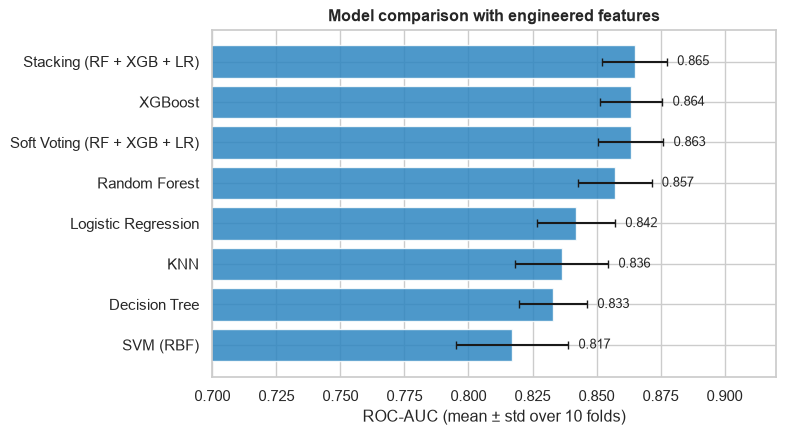

In [6]:
plot = results.sort_values("roc_auc")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot["model"], plot["roc_auc"], xerr=plot["roc_auc_std"], color=STAY, alpha=0.85, capsize=3)
for i, (v, sd) in enumerate(zip(plot["roc_auc"], plot["roc_auc_std"])):
    ax.text(v + sd + 0.004, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0.7, 0.92)
ax.set_xlabel("ROC-AUC (mean ± std over 10 folds)")
ax.set_title("Model comparison with engineered features", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the comparison**
- Feature engineering matters most for **Logistic Regression** (large ROC-AUC gain), because the bands expose
  non-linear effects a linear model cannot learn by itself. Tree-based models already capture them.
- **XGBoost, stacking and soft voting are statistically tied** (differences are well within one standard deviation).
- We keep **XGBoost** as the final model: same accuracy as the ensembles, but one model that is faster to train,
  easier to explain and simpler to maintain.

## 3. Final model on the held-out test set

In [7]:
final = make_pipeline(base_models()["XGBoost"], ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL)

# Choose the decision threshold on out-of-fold training predictions (never on the test set)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
oof = cross_val_predict(final, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
thresholds = np.arange(0.2, 0.61, 0.01)
f1s = [f1_score(y_train, oof >= t) for t in thresholds]
best_t = float(thresholds[int(np.argmax(f1s))])
print(f"F1-optimal threshold from out-of-fold predictions: {best_t:.2f}")

final.fit(X_train, y_train)
test_score = final.predict_proba(X_test)[:, 1]

summary = []
for label, t in [("Default threshold 0.50", 0.5), (f"Tuned threshold {best_t:.2f}", best_t)]:
    pred = test_score >= t
    summary.append({"setting": label, "roc_auc": roc_auc_score(y_test, test_score),
                    "accuracy": (pred == y_test).mean(), "precision": precision_score(y_test, pred),
                    "recall": recall_score(y_test, pred), "f1": f1_score(y_test, pred)})
test_summary = pd.DataFrame(summary)
test_summary.to_csv(FIGURES_DIR.parent / "test_metrics.csv", index=False)
test_summary

F1-optimal threshold from out-of-fold predictions: 0.35


,setting,roc_auc,accuracy,precision,recall,f1
0,Default threshold 0.50,0.860,0.869,0.779,0.494,0.605
1,Tuned threshold 0.35,0.860,0.855,0.650,0.617,0.633


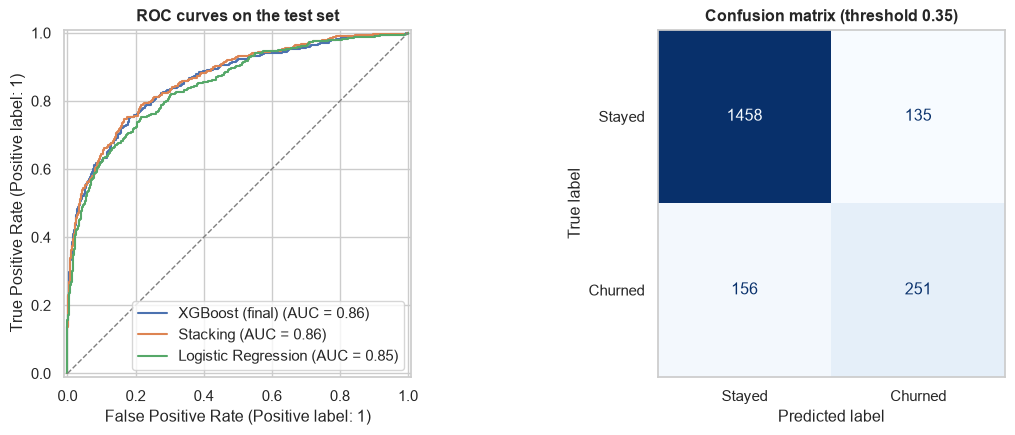

              precision    recall  f1-score   support

      Stayed       0.90      0.92      0.91      1593
     Churned       0.65      0.62      0.63       407

    accuracy                           0.85      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, model in [("XGBoost (final)", final),
                    ("Stacking", make_pipeline(ensemble_models()["Stacking (RF + XGB + LR)"],
                                               ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL)),
                    ("Logistic Regression", make_pipeline(base_models()["Logistic Regression"],
                                                          ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL))]:
    if model is not final:
        model.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], ls="--", c="grey", lw=1)
axes[0].set_title("ROC curves on the test set", fontweight="bold")

ConfusionMatrixDisplay.from_predictions(y_test, test_score >= best_t, display_labels=["Stayed", "Churned"],
                                        cmap="Blues", colorbar=False, ax=axes[1])
axes[1].set_title(f"Confusion matrix (threshold {best_t:.2f})", fontweight="bold")
axes[1].grid(False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "roc_and_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_test, test_score >= best_t, target_names=["Stayed", "Churned"]))

## 4. What drives the prediction?

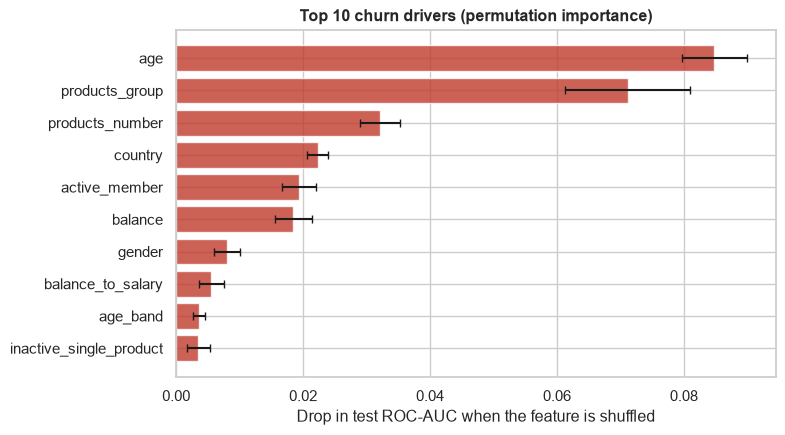

,feature,importance,std
3,age,0.085,0.005
13,products_group,0.071,0.010
6,products_number,0.032,0.003
1,country,0.022,0.002
8,active_member,0.019,0.003
5,balance,0.018,0.003
2,gender,0.008,0.002
12,balance_to_salary,0.006,0.002
10,age_band,0.004,0.001
14,inactive_single_product,0.004,0.002


In [9]:
raw_cols = [c for c in X_test.columns]
imp = permutation_importance(final, X_test, y_test, scoring="roc_auc", n_repeats=10,
                             random_state=SEED, n_jobs=-1)
importance = (pd.DataFrame({"feature": raw_cols, "importance": imp.importances_mean, "std": imp.importances_std})
              .sort_values("importance", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(8, 4.5))
plot = importance.iloc[::-1]
ax.barh(plot["feature"], plot["importance"], xerr=plot["std"], color=CHURN, alpha=0.8, capsize=3)
ax.set_xlabel("Drop in test ROC-AUC when the feature is shuffled")
ax.set_title("Top 10 churn drivers (permutation importance)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
importance

The model confirms the EDA: **age, product count and activity** dominate, followed by country and balance.
These are all levers a retention team can segment on.

## 5. From scores to a retention decision

### 5.1 Cumulative gains: how many churners do we reach by targeting the riskiest customers?

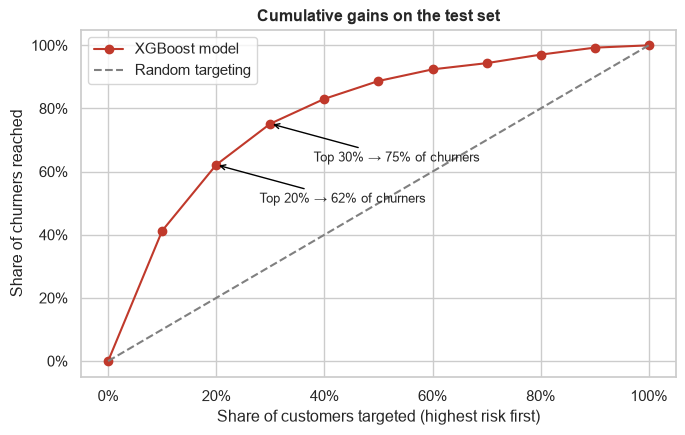

,customers,churners,churn_rate,cum_customers_pct,cum_churners_captured_pct,lift
decile,,,,,,
1,200,168,0.840,0.100,0.413,4.128
2,200,85,0.425,0.200,0.622,2.088
3,200,53,0.265,0.300,0.752,1.302
4,200,32,0.160,0.400,0.830,0.786
5,200,23,0.115,0.500,0.887,0.565
6,200,15,0.075,0.600,0.924,0.369
7,200,8,0.040,0.700,0.943,0.197
8,200,11,0.055,0.800,0.971,0.270
9,200,9,0.045,0.900,0.993,0.221


In [10]:
gains = gains_table(y_test, test_score)
gains.to_csv(FIGURES_DIR.parent / "gains_table.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.r_[0, gains["cum_customers_pct"]]
ax.plot(x, np.r_[0, gains["cum_churners_captured_pct"]], marker="o", c=CHURN, label="XGBoost model")
ax.plot([0, 1], [0, 1], ls="--", c="grey", label="Random targeting")
for pct in (0.2, 0.3):
    val = gains.loc[gains["cum_customers_pct"].round(2) == pct, "cum_churners_captured_pct"].iloc[0]
    ax.annotate(f"Top {pct:.0%} → {val:.0%} of churners", (pct, val), xytext=(pct + 0.08, val - 0.12),
                arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Share of customers targeted (highest risk first)")
ax.set_ylabel("Share of churners reached")
ax.set_title("Cumulative gains on the test set", fontweight="bold")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cumulative_gains.png", dpi=150, bbox_inches="tight")
plt.show()
gains

### 5.2 Illustrative campaign ROI

The dataset has no revenue or offer-cost data, so the numbers below are **assumptions for illustration**.
The point is the method: combine the model's ranking with unit economics to decide *how deep* to target.

| Assumption | Value |
|---|---|
| Value of keeping a customer for a year | $500 |
| Cost of a retention offer per targeted customer | $50 |
| Share of would-be churners the offer actually saves | 30% |

Best depth: target the top 19% riskiest customers (374 of 2,000), reaching 249 of 407 churners → expected profit $18,650
Targeting everyone instead: expected profit $-38,950


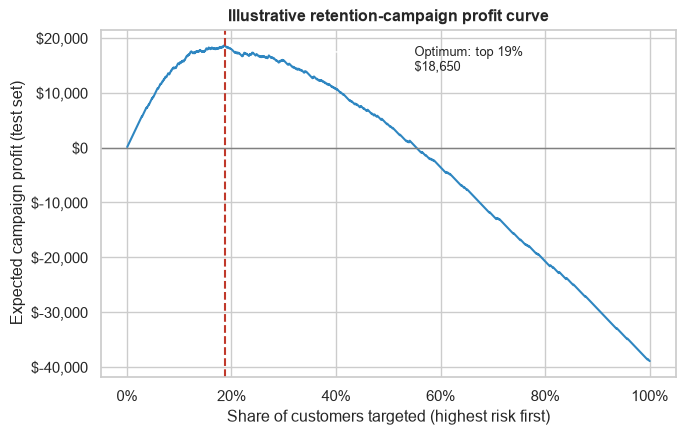

In [11]:
VALUE, COST, SAVE_RATE = 500, 50, 0.30
camp = retention_campaign_profit(y_test, test_score, VALUE, COST, SAVE_RATE)
best = camp.loc[camp["expected_profit"].idxmax()]
everyone = camp.iloc[-1]
print(f"Best depth: target the top {best.pct_targeted:.0%} riskiest customers "
      f"({int(best.customers_targeted):,} of {len(camp):,}), reaching {int(best.churners_reached)} of "
      f"{int(everyone.churners_reached)} churners → expected profit ${best.expected_profit:,.0f}")
print(f"Targeting everyone instead: expected profit ${everyone.expected_profit:,.0f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(camp["pct_targeted"], camp["expected_profit"], c=STAY)
ax.axvline(best.pct_targeted, ls="--", c=CHURN)
ax.axhline(0, c="grey", lw=1)
ax.annotate(f"Optimum: top {best.pct_targeted:.0%}\n${best.expected_profit:,.0f}",
            (best.pct_targeted, best.expected_profit), xytext=(0.55, best.expected_profit * 0.75),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_xlabel("Share of customers targeted (highest risk first)")
ax.set_ylabel("Expected campaign profit (test set)")
ax.set_title("Illustrative retention-campaign profit curve", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "campaign_profit.png", dpi=150, bbox_inches="tight")
plt.show()

## Recommendations

1. **Score customers monthly and target by risk, not by blanket campaigns.** A small, high-risk slice of the base
   holds most of the churners; targeting everyone turns a profitable campaign into a loss.
2. **Tailor the offer to the driver**: re-activation nudges for inactive members, a second-product offer for
   single-product customers, and a dedicated review of the German market and of 3-4 product bundles.
3. **Measure incrementality**: run the campaign with a random hold-out group so the real save rate replaces the
   30% assumption, then re-tune the targeting depth.

**Limitations:** one public dataset from a single bank, no time dimension (we cannot see *when* customers leave)
and no revenue data; the ROI section is a method demonstration, not a forecast.